# *CIFAR-10 Image Classification - Project*

#### Part 1 Introduction

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.
And for this project i will user CNN or Convolutional Neural Network, why i use this model? let get dive deep to it.

#### Part 2 Architecture

<img src="https://developers.google.com/static/machine-learning/practica/image-classification/images/cnn_architecture.svg" alt="CNN Architecture">

Source : https://shorturl.at/Pu5Pj

So the architecture start with a image that been transform into matrix(tensor) and using process extraction in Conv. Module #1 and Conv. Module #2 and end with classification process

#### Part 3. Image Classification

In [1]:
#Import library
import tensorflow as tf

print("The version of tensorflow is:",tf.__version__)

The version of tensorflow is: 2.18.0


In [2]:
# other imports
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPooling2D, GlobalMaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model

In [3]:
# Load dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Check shape data train
print("Shape train data:")
print("  Image:", x_train.shape)
print("  Label:", y_train.shape)
print('check the train data: \n', x_train[0])
print(' ')
print('check the train data label \n', y_train[0])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Shape train data:
  Image: (50000, 32, 32, 3)
  Label: (50000, 1)
check the train data: 
 [[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
 
check the train data label 
 [6]


In [4]:
# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

# Rearrange the label data
y_train, y_test = y_train.flatten(), y_test.flatten()

In [5]:
print('check the train data: \n', x_train[0])
print(' ')
print('check the train data label \n', y_train[0])

check the train data: 
 [[[0.23137255 0.24313725 0.24705882]
  [0.16862745 0.18039216 0.17647059]
  [0.19607843 0.18823529 0.16862745]
  ...
  [0.61960784 0.51764706 0.42352941]
  [0.59607843 0.49019608 0.4       ]
  [0.58039216 0.48627451 0.40392157]]

 [[0.0627451  0.07843137 0.07843137]
  [0.         0.         0.        ]
  [0.07058824 0.03137255 0.        ]
  ...
  [0.48235294 0.34509804 0.21568627]
  [0.46666667 0.3254902  0.19607843]
  [0.47843137 0.34117647 0.22352941]]

 [[0.09803922 0.09411765 0.08235294]
  [0.0627451  0.02745098 0.        ]
  [0.19215686 0.10588235 0.03137255]
  ...
  [0.4627451  0.32941176 0.19607843]
  [0.47058824 0.32941176 0.19607843]
  [0.42745098 0.28627451 0.16470588]]

 ...

 [[0.81568627 0.66666667 0.37647059]
  [0.78823529 0.6        0.13333333]
  [0.77647059 0.63137255 0.10196078]
  ...
  [0.62745098 0.52156863 0.2745098 ]
  [0.21960784 0.12156863 0.02745098]
  [0.20784314 0.13333333 0.07843137]]

 [[0.70588235 0.54509804 0.37647059]
  [0.67843137

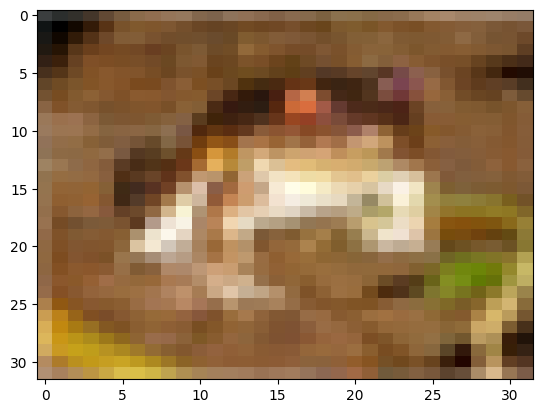

In [6]:
# Check the visualization of the data
fig, ax = plt.subplots(1,1)

ax.imshow(x_train[0], aspect='auto')

plt.show()

In [7]:
# Build the model
i = Input(shape=(32, 32, 3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Flatten()(x)
x = Dropout(0.2)(x)

x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(10, activation='softmax')(x)

model = Model(i, x)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,397,226 (9.14 MB)

 Trainable params: 2,396,330 (9.14 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
results = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - accuracy: 0.4518 - loss: 1.7322 - val_accuracy: 0.6083 - val_loss: 1.1456
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.6948 - loss: 0.8729 - val_accuracy: 0.7192 - val_loss: 0.8395
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7566 - loss: 0.6878 - val_accuracy: 0.7713 - val_loss: 0.6772
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8026 - loss: 0.5713 - val_accuracy: 0.7752 - val_loss: 0.6749
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8346 - loss: 0.4840 - val_accuracy: 0.7843 - val_loss: 0.6681
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8635 - loss: 0.3923 - val_accuracy: 0.7923 - val_loss: 0.6794
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8850 - loss: 0.3357 - val_accuracy: 0.8029 - val_loss: 0.6544
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8996 - loss: 

In [10]:
# Using data augmentation
batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)

train_generator = data_generator.flow(x_train, y_train, batch_size)
steps_per_epoch = x_train.shape[0] // batch_size

r = model.fit(train_generator, validation_data=(x_test, y_test),
              steps_per_epoch=steps_per_epoch, epochs=50)

Epoch 1/50
   4/1562 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.7943 - loss: 1.1641 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.8119 - loss: 0.6207 - val_accuracy: 0.8382 - val_loss: 0.5232
Epoch 2/50
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8125 - loss: 0.5663

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - accuracy: 0.8125 - loss: 0.5663 - val_accuracy: 0.8393 - val_loss: 0.5205
Epoch 3/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.8577 - loss: 0.4395 - val_accuracy: 0.8363 - val_loss: 0.5231
Epoch 4/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - accuracy: 0.8125 - loss: 0.5518 - val_accuracy: 0.8365 - val_loss: 0.5211
Epoch 5/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.8654 - loss: 0.4077 - val_accuracy: 0.8552 - val_loss: 0.4598
Epoch 6/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 603us/step - accuracy: 0.7812 - loss: 0.7381 - val_accuracy: 0.8549 - val_loss: 0.4588
Epoch 7/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.8756 - loss: 0.3782 - val_accuracy: 0.8600 - val_loss: 0.4331
Epoch 8/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step - accuracy: 0.7812 - loss: 0.3326 - val_accuracy: 0.8596 - val_loss: 0.4326
Epoch 9/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.8789 - loss: 0.35

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Classification report: 
              precision    recall  f1-score   support

    airplane       0.89      0.89      0.89      1000
  automobile       0.93      0.95      0.94      1000
        bird       0.86      0.79      0.82      1000
         cat       0.84      0.66      0.74      1000
        deer       0.83      0.89      0.86      1000
         dog       0.82      0.80      0.81      1000
        frog       0.80      0.94      0.87      1000
       horse       0.92      0.91      0.91      1000
        ship       0.93      0.93      0.93      1000
       truck       0.90      0.95      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



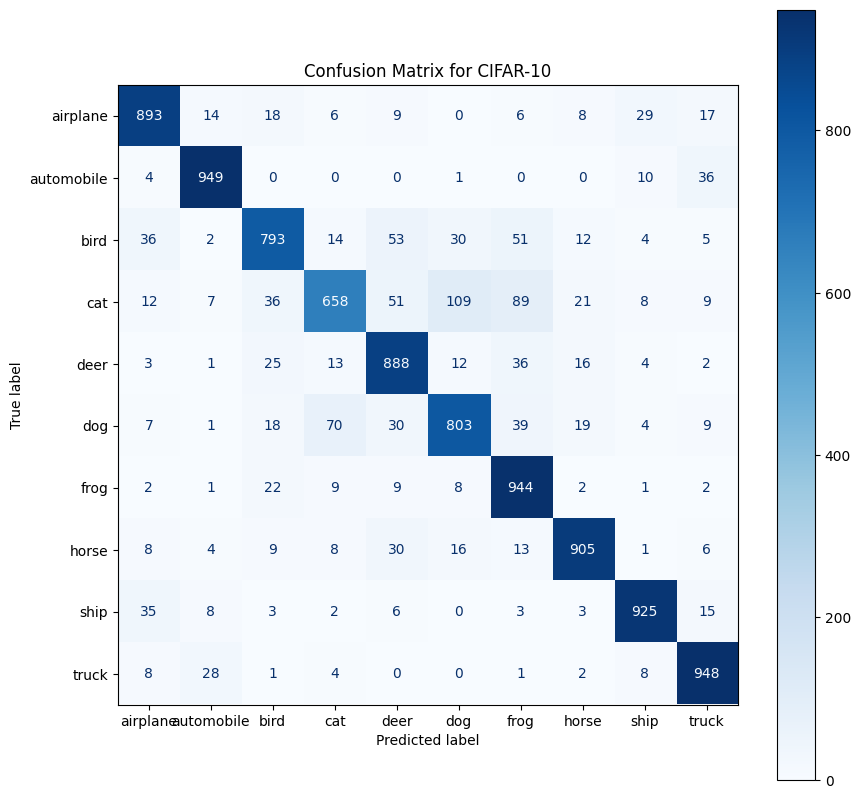

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# prediction
y_pred = model.predict(x_test)

# get max prob class
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print('Classification report: ')
print(classification_report(y_test.flatten(), np.argmax(y_pred, axis=1), target_names=[
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]))

# Make confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# label data
labels = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix for CIFAR-10')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step
Original labels is cat and predicted label is cat


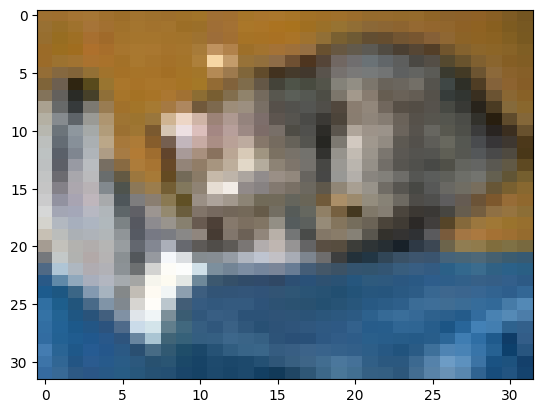

In [11]:
# Start predicting
labels = '''
airplane automobile bird cat deerdog frog horseship truck
'''.split()

# select number image
image_number = 0

# load the image in array
n = np.array(x_test[image_number])

# reshape
p = n.reshape(1, 32, 32, 3)

# predicted label process
predicted_label = labels[model.predict(p).argmax()]

# load original label
original_label = labels[y_test[image_number]]

# display result predicted
print("Original labels is {} and predicted label is {}".format(
    original_label, predicted_label
))

fig, ax = plt.subplots(1,1)

ax.imshow(x_test[0], aspect='auto')

plt.show()

In [12]:
# import numpy as np
# import matplotlib.pyplot as plt
# from tensorflow.keras.models import load_model
# from google.colab import files
# from PIL import Image

# # --- Load your trained model  ---
# # model = load_model('path_to_your_saved_model.h5')

# # --- CIFAR-10 labels ---
# labels = '''
# airplane automobile bird cat deer dog frog horse ship truck
# '''.split()

# # --- Upload image ---
# uploaded = files.upload()

# for file_name in uploaded.keys():
#     # Load image
#     img = Image.open(file_name)
#     img = img.resize((32, 32))  # CIFAR-10 ukuran 32x32
#     img_array = np.array(img)

#     # If image grayscale change to RGB format
#     if img_array.ndim == 2:
#         img_array = np.stack((img_array,)*3, axis=-1)
#     elif img_array.shape[-1] == 4:
#         # If RGBA delete Alpha
#         img_array = img_array[..., :3]

#     # Normalize
#     img_array = img_array / 255.0

#     # Change for prediction
#     p = img_array.reshape(1, 32, 32, 3)

#     # Prediction
#     prediction = model.predict(p)
#     predicted_label = labels[prediction.argmax()]

#     # --- Printing Result ---
#     print(f"Predicted label: {predicted_label}")

#     plt.imshow(img_array)
#     plt.title(f"Predicted: {predicted_label}")
#     plt.axis('off')
#     plt.show()

In [25]:
model.save('cifar10_classification_model_30052025.h5')